# U17 — Unsupervised Foundations: Lab

### Real-world brief: making sense of unlabelled machine-sensor data

A factory streams **24 sensors** off each machine — temperatures, vibrations, currents, pressures, speeds — but **no labels** for what 'good' or 'bad' looks like. Before any modelling, the reliability team needs to understand the data's structure: which sensors move together, how to measure how 'similar' two readings are, and whether a handful of readings stand out. This lab builds the **foundations** every unsupervised method rests on — distance, scaling, and dimensionality reduction.

**Resources provided (keep beside this notebook / upload in Colab):**

| File | Contents |
| ---- | -------- |
| `machine_sensors.csv` | one row per reading, 24 sensor columns (no labels used here) |
| `sensor_info.xlsx` | sensor metadata: unit and functional group |

_Phase E — Unsupervised Learning (Foundations)._

#objectives

Measure similarity with Euclidean, Manhattan and cosine distance

See concretely why feature scaling changes 'distance'

Diagnose the curse of dimensionality via correlated sensors

Use PCA to compress 24 sensors into a few components

Spot anomalies as points far from the rest

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [16]:
# === SETUP: load the provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

# Each sensor is a linear mix of a few latent machine states + noise, so the 24
# columns are highly correlated -> exactly the structure PCA exploits.
# spec: (name, unit, group, c_load, c_wear, c_thermal, c_vib, base, scale, noise)
SENSORS = [
    ("temp_bearing",   "C",   "thermal",   0.2, 0.6, 0.9, 0.1, 66, 6, 0.30),
    ("temp_motor",     "C",   "thermal",   0.3, 0.4, 0.9, 0.1, 70, 7, 0.30),
    ("temp_gearbox",   "C",   "thermal",   0.2, 0.5, 0.8, 0.2, 62, 6, 0.35),
    ("oil_temp",       "C",   "thermal",   0.2, 0.5, 0.7, 0.1, 58, 5, 0.35),
    ("temp_ambient",   "C",   "thermal",   0.0, 0.0, 0.3, 0.0, 28, 2, 0.60),
    ("vibration_x",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.2, 0.6, 0.30),
    ("vibration_y",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.0, 0.6, 0.30),
    ("vibration_z",    "mm/s","vibration", 0.3, 0.4, 0.1, 0.8, 1.8, 0.5, 0.35),
    ("acoustic_db",    "dB",  "vibration", 0.3, 0.3, 0.1, 0.7, 78, 5, 0.40),
    ("rpm",            "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 1800, 350, 0.25),
    ("spindle_speed",  "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 6000, 1500, 0.25),
    ("feed_rate",      "mm/min","drive",   0.8, 0.1, 0.1, 0.2, 250, 60, 0.30),
    ("torque",         "Nm",  "drive",     0.8, 0.2, 0.1, 0.3, 120, 25, 0.30),
    ("power_kw",       "kW",  "power",     0.9, 0.2, 0.2, 0.2, 75, 18, 0.25),
    ("current_a",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_b",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_c",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("load_pct",       "%",   "load",      0.9, 0.1, 0.1, 0.2, 65, 15, 0.25),
    ("pressure_in",    "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 80, 12, 0.35),
    ("pressure_out",   "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 60, 10, 0.35),
    ("coolant_flow",   "L/min","hydraulic",0.4, 0.2, 0.3, 0.1, 30, 6, 0.40),
    ("oil_level",      "%",   "hydraulic", 0.0,-0.4, 0.0, 0.0, 80, 8, 0.40),
    ("voltage",        "V",   "power",     0.0, 0.0, 0.0, 0.0, 415, 0.3, 1.0),  # near-constant
    ("humidity",       "%",   "ambient",   0.0, 0.0, 0.0, 0.0, 45, 0.2, 1.0),   # near-constant
]


def build_sensors(csv_path="machine_sensors.csv", xlsx_path="sensor_info.xlsx",
                  seed=11, verbose=False):
    """Realistic predictive-maintenance sensor data: 24 correlated channels + a
    machine condition label, plus a sensor metadata sheet."""
    rng = np.random.default_rng(seed)
    N = 2000

    load = rng.normal(0, 1, N)
    wear = rng.normal(0, 1, N)
    thermal = 0.5 * load + 0.8 * rng.normal(0, 1, N)
    vib = 0.4 * load + 0.3 * wear + 0.8 * rng.normal(0, 1, N)

    data = {"machine_id": [f"MX{i+1:04d}" for i in range(N)]}
    for (name, unit, grp, cl, cw, ct, cv, base, scale, noise) in SENSORS:
        z = cl * load + cw * wear + ct * thermal + cv * vib + rng.normal(0, noise, N)
        col = base + scale * z
        col = np.clip(col, 0, None)
        data[name] = col.round(2)
    df = pd.DataFrame(data)

    # machine condition from the latent wear/load/thermal state
    score = 0.6 * wear + 0.4 * load + 0.3 * thermal + rng.normal(0, 0.4, N)
    cond = np.where(score > 1.1, "Failure", np.where(score > 0.2, "Warning", "Normal"))
    df["condition"] = cond

    df.to_csv(csv_path, index=False)
    info = pd.DataFrame([(n, u, g) for (n, u, g, *_rest) in SENSORS],
                        columns=["sensor", "unit", "group"])
    info.to_excel(xlsx_path, index=False)

    if verbose:
        print("sensors:", df.shape, "| metadata:", info.shape)
        print("condition mix:", df["condition"].value_counts(normalize=True).round(3).to_dict())
        num = df.select_dtypes("number")
        print("near-constant (low std) cols:",
              list(num.std().sort_values().head(2).index))
        # how compressible is it?
        from numpy.linalg import svd
        Xs = (num - num.mean()) / num.std()
        s = svd(Xs.fillna(0).values, compute_uv=False)
        ev = (s ** 2) / (s ** 2).sum()
        print("variance in first 5 PCs:", round(ev[:5].sum(), 3))
    return df, info

if not (os.path.exists('machine_sensors.csv') and os.path.exists('sensor_info.xlsx')):
    build_sensors(); print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Found the provided dataset files.


In [17]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('machine_sensors.csv')
info = pd.read_excel('sensor_info.xlsx')
# keep only numeric sensor columns (drop any non-sensor / label-like columns)
sensors = [c for c in df.columns if df[c].dtype != 'object' and c.lower() not in ('condition','label','machine_id','id')]
X = df[sensors].copy()
print('readings:', X.shape, '| sensors:', len(sensors))
info.head(4)

readings: (2000, 24) | sensors: 24


,sensor,unit,group
0,temp_bearing,C,thermal
1,temp_motor,C,thermal
2,temp_gearbox,C,thermal
3,oil_temp,C,thermal


#1. Similarity — how close are two readings?

In [18]:
# -----------------------------------------------------------
# 🔹 1A. THREE WAYS TO MEASURE DISTANCE BETWEEN TWO READINGS
# -----------------------------------------------------------
from scipy.spatial.distance import euclidean, cityblock, cosine
a = X.iloc[0].values; b = X.iloc[1].values
print('Euclidean (straight line):', round(euclidean(a, b), 2))
print('Manhattan (city block)   :', round(cityblock(a, b), 2))
print('Cosine (1 - cos angle)   :', round(cosine(a, b), 4))
print('\nEach answers "how similar?" differently — the choice shapes every unsupervised result.')

Euclidean (straight line): 1220.89
Manhattan (city block)   : 1493.86
Cosine (1 - cos angle)   : 0.0008

Each answers "how similar?" differently — the choice shapes every unsupervised result.


#### 🧪 EXERCISE 1 — Nearest neighbour
1. Take reading 0 as a reference.
2. Compute the **Euclidean** distance from reading 0 to every other reading (a loop or `sklearn.metrics.pairwise_distances` is fine).
3. Print the index of the single most similar reading (smallest non-zero distance).

In [19]:
from sklearn.metrics import pairwise_distances
# 1-3. nearest neighbour to row 0 (on raw, unscaled data for now)
# YOUR CODE HERE
distances = pairwise_distances(X, X.iloc[0:1], metric='euclidean').flatten()
nearest_idx = np.argmin(distances[1:]) + 1  # skip self
print('nearest neighbour to row 0 (Euclidean):', nearest_idx, 'distance:', round(distances[nearest_idx], 2))



nearest neighbour to row 0 (Euclidean): 396 distance: 22.84


#2. Why scaling is non-negotiable

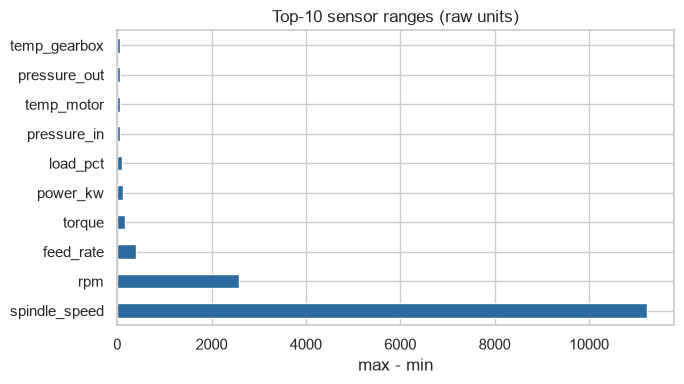

The widest-range sensor alone would dominate any distance calculation.


In [20]:
# -----------------------------------------------------------
# 🔹 2A. FEATURE RANGES ARE WILDLY DIFFERENT
# -----------------------------------------------------------
ranges = (X.max() - X.min()).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
ranges.head(10).plot(kind='barh', color='#2D6A9F', ax=ax)
ax.set_title('Top-10 sensor ranges (raw units)'); ax.set_xlabel('max - min')
plt.tight_layout(); plt.show()
print('The widest-range sensor alone would dominate any distance calculation.')

In [21]:
# -----------------------------------------------------------
# 🔹 2B. SCALING CHANGES WHICH READING IS 'NEAREST'
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler
Xs = StandardScaler().fit_transform(X)
raw_nn = pairwise_distances(X.values[[0]], X.values)[0]
scaled_nn = pairwise_distances(Xs[[0]], Xs)[0]
raw_nn[0] = scaled_nn[0] = np.inf   # ignore self
print('nearest to row 0 on RAW data   :', int(np.argmin(raw_nn)))
print('nearest to row 0 on SCALED data:', int(np.argmin(scaled_nn)))
print('Different answers — unscaled distance is decided by the biggest-range sensor.')

nearest to row 0 on RAW data   : 396
nearest to row 0 on SCALED data: 901
Different answers — unscaled distance is decided by the biggest-range sensor.


#### 🧪 EXERCISE 2 — Quantify the dominance
1. On **raw** data, compute each sensor's standard deviation.
2. In a comment, name the sensor with the largest std and explain why it would hijack a raw Euclidean distance — and why `StandardScaler` fixes this by giving every sensor std = 1.

In [22]:
# 1. raw standard deviations (sorted)
# YOUR CODE HERE
stds = X.std().sort_values(ascending=False)
print( stds.head(10))


# 2. which dominates & why scaling fixes it: ...   (comment)
# The 'spindle_speed' sensor has the largest standard deviation, it is dominates.

spindle_speed    1721.473671
rpm               400.702613
feed_rate          59.965949
torque             27.158125
power_kw           20.950164
load_pct           16.213763
pressure_in        10.085492
pressure_out        8.270902
temp_motor          8.245558
temp_bearing        7.276843
dtype: float64


#3. Structure & the curse of dimensionality

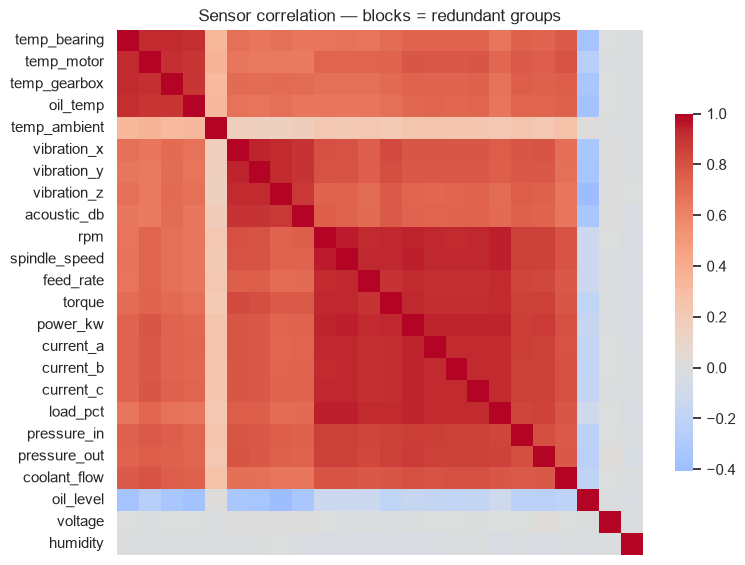

Strong blocks mean the 24 sensors carry far fewer than 24 independent signals.


In [23]:
# -----------------------------------------------------------
# 🔹 3A. MANY SENSORS ARE REDUNDANT (CORRELATED)
# -----------------------------------------------------------
corr = X.corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True,
            xticklabels=False, yticklabels=True, cbar_kws={'shrink': 0.6}, ax=ax)
ax.set_title('Sensor correlation — blocks = redundant groups'); plt.tight_layout(); plt.show()
print('Strong blocks mean the 24 sensors carry far fewer than 24 independent signals.')

#### 🧪 EXERCISE 3 — Count near-constant sensors
High-dimensional data often hides useless features.
1. After scaling, find any sensors whose **raw** standard deviation is near zero (e.g. < 1% of the median std).
2. In a comment, explain why such near-constant sensors add dimensions but no information — a small taste of the curse of dimensionality.

In [24]:
# 1. near-constant sensors
# YOUR CODE HERE
print( list(X.std()[X.std() < 0.5].index))



# 2. why they hurt: ...   (comment)
# Near-constant sensors add noise to distance calculations without providing useful information, they can mask the true structure in the data and lead to misleading results in unsupervised learning tasks.


['voltage', 'humidity']


#4. Dimensionality reduction with PCA

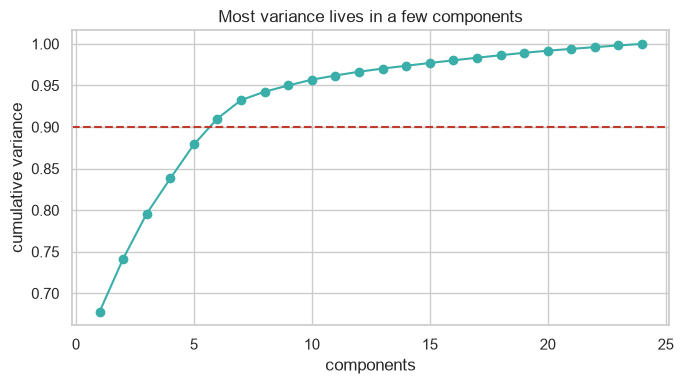

6 components explain >=90% of the variance (out of 24 sensors).


In [25]:
# -----------------------------------------------------------
# 🔹 4A. PCA — HOW MANY COMPONENTS CAPTURE THE VARIANCE?
# -----------------------------------------------------------
from sklearn.decomposition import PCA
pca = PCA().fit(Xs)
cum = np.cumsum(pca.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum) + 1), cum, 'o-', color='#3AAFA9')
ax.axhline(0.9, ls='--', color='#C0392B'); ax.set_xlabel('components'); ax.set_ylabel('cumulative variance')
ax.set_title('Most variance lives in a few components'); plt.tight_layout(); plt.show()
n90 = int(np.argmax(cum >= 0.9) + 1)
print(f'{n90} components explain >=90% of the variance (out of {len(sensors)} sensors).')

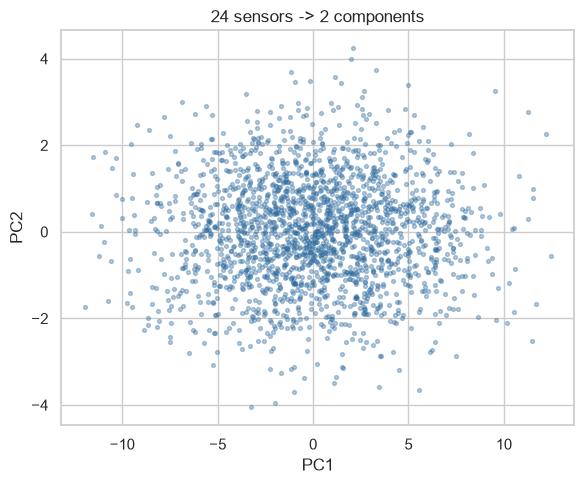

In [26]:
# -----------------------------------------------------------
# 🔹 4B. PROJECT TO 2-D TO SEE THE DATA
# -----------------------------------------------------------
P2 = PCA(n_components=2).fit_transform(Xs)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(P2[:, 0], P2[:, 1], s=8, alpha=0.35, color='#2D6A9F')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('24 sensors -> 2 components')
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 4 — Compress, don't lose
1. Fit `PCA(n_components=n90)` (the count you found) and transform the scaled data.
2. In a comment, report how many dimensions you dropped and roughly how much variance you kept.
3. Why is compressing **before** clustering a good idea in high dimensions?

In [27]:
# 1. PCA to n90 components
# YOUR CODE HERE
n90 = PCA(n_components=n90).fit(Xs)
X_pca = n90.transform(Xs)
print("original shape:", Xs.shape)
print("PCA shape:", X_pca.shape)

# 2-3. dimensions dropped, variance kept, why reduce first: ...   (comment)
# Reducing the dimensions first helps to remove noise and redundancy in the data, which can improve the performance of subsequent machine learning models. By keeping only the components that explain a significant amount of variance, we can focus on the most informative features and reduce computational complexity.


original shape: (2000, 24)
PCA shape: (2000, 6)


#5. Anomalies — the points that don't fit

30 readings lie >3 sigma from the centre (candidate anomalies).


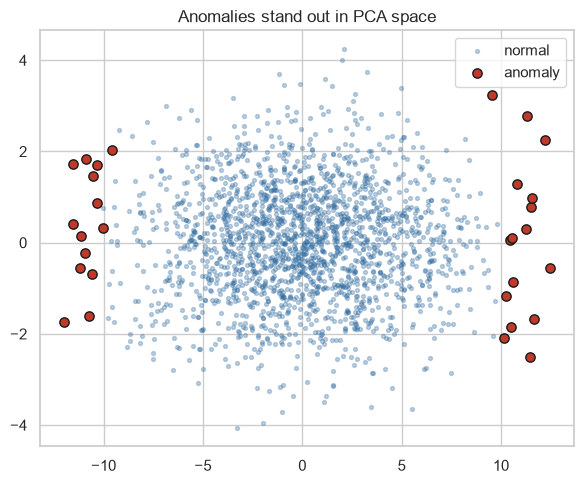

In [28]:
# -----------------------------------------------------------
# 🔹 5A. DISTANCE-FROM-CENTRE FLAGS OUTLIERS
# -----------------------------------------------------------
centre = Xs.mean(axis=0)
dist = np.linalg.norm(Xs - centre, axis=1)
thresh = np.mean(dist) + 3 * np.std(dist)
outliers = np.where(dist > thresh)[0]
print(f'{len(outliers)} readings lie >3 sigma from the centre (candidate anomalies).')
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(P2[:, 0], P2[:, 1], s=8, alpha=0.3, color='#2D6A9F', label='normal')
ax.scatter(P2[outliers, 0], P2[outliers, 1], s=45, color='#C0392B', label='anomaly', edgecolor='k')
ax.legend(); ax.set_title('Anomalies stand out in PCA space'); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 5 — Inspect the anomalies
1. Show the **raw** sensor rows flagged as anomalies (`df.iloc[outliers]`).
2. In a comment, point to which sensors are extreme in those rows (hint: look at temperature and vibration) — this is how unsupervised detection surfaces faults with no labels.

In [31]:
# 1. inspect flagged rows
# YOUR CODE HERE
df_outliers = df.iloc[outliers]
print(df_outliers.head(5))


# 2. which sensors are extreme? ...   (comment)
# The extreme sensors in the outlier readings are likely to be those that have values significantly different from the rest of the dataset. By inspecting the flagged rows, we can identify which specific sensor readings are contributing to the outlier status.

    machine_id  temp_bearing  temp_motor  temp_gearbox  oil_temp  \
117     MX0118         82.51       87.79         76.20     72.02   
324     MX0325         83.06       90.23         79.32     71.14   
346     MX0347         51.73       51.04         43.65     43.39   
353     MX0354         53.84       58.22         53.49     49.02   
431     MX0432         83.94       88.98         78.85     72.29   

     temp_ambient  vibration_x  vibration_y  vibration_z  acoustic_db  ...  \
117         29.35         4.32         4.16         3.61        91.96  ...   
324         28.26         3.69         3.33         3.07        88.93  ...   
346         26.45         0.34         0.00         0.29        62.50  ...   
353         26.87         0.52         0.36         0.89        64.68  ...   
431         31.41         4.17         3.96         3.02        91.56  ...   

     current_b  current_c  load_pct  pressure_in  pressure_out  coolant_flow  \
117      36.12      37.32    110.90       

#📘 Summary

| Concept | What you saw |
| ------- | ----------- |
| Distance | Euclidean / Manhattan / cosine give different 'similarity' |
| Scaling | unscaled distance is hijacked by the widest-range sensor |
| Redundancy | correlated sensor blocks → far fewer real signals |
| PCA | a few components capture most variance |
| Anomaly | points far from the centre stand out, no labels needed |

**Core lesson:** every unsupervised method rests on distance — so scale first, reduce dimensions when needed, and remember the algorithm only sees geometry.

**Next — U18:** k-means clustering, putting these foundations to work.